**Đọc file dataset**  https://www.kaggle.com/datasets/shivamb/go-emotions-google-emotions-dataset/data

In [ ]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "go_emotions_dataset.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/go-emotions-google-emotions-dataset",
    file_path
)

# Khai báo cấu trúc hệ thống phân loại 28 nhãn chuẩn của Google
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]



/tmp/ipykernel_751/2057014050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'go-emotions-google-emotions-dataset' dataset.


**Gom cụm các rater** nếu > 2 người cùng đánh giá 1 câu cùng 1 loại cảm xúc thì giữ, còn lại bỏ

In [ ]:
# Gom cụm các rater đánh giá cùng một câu bình luận lại với nhau
grouped = df.groupby(['id', 'text'])[emotion_labels].sum().reset_index()
print(f"Số lượng câu bình luận độc nhất sau khi gom cụm: {len(grouped)} câu.")

# Nhãn cảm xúc nào được ít nhất 2 chuyên gia chọn mới tính là 1, dưới 2 phiếu bầu sẽ bị hủy (= 0)
for col in emotion_labels:
    grouped[col] = (grouped[col] >= 2).astype(int)

# Tính tổng số nhãn được kích hoạt cho mỗi câu
grouped['has_label'] = grouped[emotion_labels].sum(axis=1)
# Chỉ giữ lại các câu có ít nhất 1 nhãn cảm xúc đạt sự đồng thuận từ 2 người trở lên
grouped_clean = grouped[grouped['has_label'] > 0].drop(columns=['has_label'])

print(f"Số lượng câu bình luận sạch thu được: {len(grouped_clean)} câu.")

grouped_clean.head(3)

Số lượng câu bình luận độc nhất sau khi gom cụm: 58011 câu.
Số lượng câu bình luận sạch thu được: 54263 câu.


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,You blew it. They played you like a fiddle.,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Làm sạch dữ liệu**

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
import unicodedata

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    # 1. Tránh lỗi crash nếu dữ liệu bị trống (NaN)
    if not isinstance(text, str):
        return ""

    # 2. Đưa về chữ thường
    text = text.lower()

    # Bước A: Đồng bộ hóa mọi loại "dấu nháy"
    text = re.sub(r"[’‘`´]", "'", text)

    # Bước B: Xử lý chữ cái có dấu
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 3. Khai triển từ viết tắt
    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"doesn't", "does not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"isn't", "is not", text)
    text = re.sub(r"aren't", "are not", text)
    text = re.sub(r"haven't", "have not", text)
    text = re.sub(r"hasn't", "has not", text)
    text = re.sub(r"didn't", "did not", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"you're", "you are", text)
    text = re.sub(r"i've", "i have", text)
    text = re.sub(r"i'll", "i will", text)

    # Vớt những cụm viết tắt đuôi còn sót
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # KỸ THUẬT NỐI TỪ PHỦ ĐỊNH
    text = re.sub(r"\bnot\s+([a-z]+)\b", r"not_\1", text)

    # 4. Lọc ký tự đặc biệt (giữ lại khoảng trắng, a-z, 0-9 và dấu biểu cảm ! ? _)
    text = re.sub(r"[^a-z0-9\s\!\?\_]", " ", text)

    # 5. Ép các ký tự lặp lại vô nghĩa (soooo -> so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 6. Gom khoảng trắng thừa và cắt tỉa
    text = re.sub(r"\s+", " ", text).strip()

    # ========================================================
    # 7. KỸ THUẬT LEMMATIZATION (Ép gốc từ) - Đã cấy vào cuối hàm
    # ========================================================
    words = text.split()
    # pos='v' giúp ép các động từ (loved, loving, loves) về nguyên thể (love)
    lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    text = " ".join(lemmatized_words)

    return text

# Chạy làm sạch trên tập dữ liệu
grouped_clean = grouped_clean.copy()
grouped_clean = grouped_clean.dropna(subset=['text'])
grouped_clean['text'] = grouped_clean['text'].apply(advanced_clean_text)
grouped_clean = grouped_clean[grouped_clean['text'] != ""]

grouped_clean.head(3)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,fast as name will carry me seriously uptown to...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,you blow it they play you like a fiddle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,tl dr no more superbowls for name get ready fo...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Chia tập train test valid**

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đầu vào X (văn bản sạch) và ma trận đầu ra Y (28 nhãn cảm xúc)
X_text = grouped_clean['text'].astype(str).values
Y_matrix = grouped_clean[emotion_labels].values

# 2. Lần tách thứ nhất: Giữ lại 80% cho tập Train, đẩy 20% còn lại vào tập tạm (Temp)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    X_text, Y_matrix, test_size=0.20, random_state=42
)

# 3. Lần tách thứ hai: Chia đôi 50/50 tập tạm (Temp) để lấy ra đúng 10% Dev và 10% Test biệt lập
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train - 80%): {X_train_text.shape[0]} câu.")
print(f"Tập Phát triển/Kiểm định (Val - 10%): {X_val_text.shape[0]} câu.")
print(f"Tập Kiểm thử (Test - 10%): {X_test_text.shape[0]} câu.")
print(f"Tổng cộng: {X_train_text.shape[0] + X_val_text.shape[0] + X_test_text.shape[0]} câu.")

Tập Huấn luyện (Train - 80%): 43408 câu.
Tập Phát triển/Kiểm định (Val - 10%): 5426 câu.
Tập Kiểm thử (Test - 10%): 5426 câu.
Tổng cộng: 54260 câu.


**TRÍCH XUẤT TF-IDF VECTORIZER**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

print("SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...")

# 1. Lấy danh sách stop_words mặc định và bảo vệ các từ phủ định
custom_stop_words = list(ENGLISH_STOP_WORDS)
words_to_keep = ['not', 'no', 'nor', 'none', 'cannot', 'nothing']

for w in words_to_keep:
    if w in custom_stop_words:
        custom_stop_words.remove(w)

# 2. Khởi tạo TF-IDF với BỘ LỌC ĐÁY và TRẦN
tfidf = TfidfVectorizer(
    max_features= 5000,
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=5,       # 🌟 LỌC ĐÁY: Bỏ qua các từ xuất hiện dưới 5 lần
    max_df=0.85     # 🌟 LỌC TRẦN: Bỏ qua các từ xuất hiện ở nhiều hơn 85% số câu
)

# 3. Tiến hành fit và transform trên tập Train
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Chỉ transform (không fit lại) trên tập Val và Test
X_temp_tfidf = tfidf.transform(X_temp_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Kích thước ma trận TF-IDF tập Train: {X_train_tfidf.shape}")

SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...
Kích thước ma trận TF-IDF tập Train: (43408, 5000)


In [ ]:
from google.colab import files

# 1. Lấy danh sách toàn bộ từ vựng đã học từ TF-IDF
learned_words = tfidf.get_feature_names_out()

# (Tùy chọn) Nếu ông CHỈ MUỐN lấy đúng 500 từ đầu tiên, thì bỏ dấu # ở dòng dưới:
# learned_words = learned_words[:500]

file_name = "Danh_sach_tu_vung_TFIDF.txt"

# 2. Ghi dữ liệu ra file text
with open(file_name, "w", encoding="utf-8") as f:
    for word in learned_words:
        f.write(word + "\n")

print(f"✅ Đã đóng gói thành công {len(learned_words)} từ ra file '{file_name}'!")

# 3. LỆNH THẦN THÁNH: Kích hoạt tải thẳng file xuống máy tính cá nhân
files.download(file_name)

✅ Đã đóng gói thành công 5000 từ ra file 'Danh_sach_tu_vung_TFIDF.txt'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Hồi quy logictic đa nhãn bằng cách tạo 28 mô hình (OvR)** + Tối ứu tham số phạt C của mô hình

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import time

print("ĐANG TÌM THAM SỐ C TỐI ƯU CHO LOGISTIC REGRESSION...")
total_start_time = time.time()

# Thử nghiệm 3 mức độ: Phạt nặng (0.1), Vừa (1.0), Nhẹ (10.0)
C_values = [0.01, 0.1, 1, 10]
best_score = 0
best_c = 1.0
best_model = None

for c_val in C_values:
    step_start_time = time.time()
    print(f"\n🔄 Đang huấn luyện với C = {c_val} ...")

    # Khai báo mô hình với tham số C
    base_model = LogisticRegression(C=c_val, class_weight='balanced', solver='liblinear', max_iter=200)
    ovr_model = OneVsRestClassifier(base_model, n_jobs=-1) # Ép chạy song song cho nhanh

    # Train mô hình
    ovr_model.fit(X_train_tfidf, Y_train)

    # Chấm điểm nhanh trên tập Val
    from sklearn.metrics import f1_score

    y_pred = ovr_model.predict(X_val_tfidf)

    score = f1_score(
             Y_val,
              y_pred,
              average='macro'
        )
    step_end_time = time.time()

    print(f"✅ ĐiểmF1: {score:.4f} (Mất {step_end_time - step_start_time:.2f} giây)")

    # So sánh và giữ lại mô hình xịn nhất
    if score > best_score:
        best_score = score
        best_c = c_val
        best_model = ovr_model

total_end_time = time.time()
print("\n" + "=" * 60)
print(f"🏆 CHỐT HẠ: Tham số TỐI ƯU NHẤT là C = {best_c} (F1 = {best_score:.4f})")
print(f"⏳ Tổng thời gian test cả {len(C_values)} cấu hình: {total_end_time - total_start_time:.2f} giây.")
print("=" * 60)

# Gán mô hình chiến thắng vào biến gốc để Cell 7, 8, 9 chạy bình thường
ovr_classifier = best_model

ĐANG TÌM THAM SỐ C TỐI ƯU CHO LOGISTIC REGRESSION...

🔄 Đang huấn luyện với C = 0.01 ...
✅ ĐiểmF1: 0.3854 (Mất 5.73 giây)

🔄 Đang huấn luyện với C = 0.1 ...
✅ ĐiểmF1: 0.3609 (Mất 2.14 giây)

🔄 Đang huấn luyện với C = 1 ...
✅ ĐiểmF1: 0.3490 (Mất 3.45 giây)

🔄 Đang huấn luyện với C = 10 ...
✅ ĐiểmF1: 0.3288 (Mất 7.08 giây)

🏆 CHỐT HẠ: Tham số TỐI ƯU NHẤT là C = 0.01 (F1 = 0.3854)
⏳ Tổng thời gian test cả 4 cấu hình: 18.39 giây.


**Đánh giá trên tập test**

In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

print("ĐANG CHẠY THUẬT TOÁN TÌM NGƯỠNG TỐI ƯU TỰ ĐỘNG TRÊN TẬP VAL...")

# =========================================================================
# BƯỚC 1: LẤY XÁC SUẤT THÔ TRÊN TẬP VAL (ĐỂ TÌM NGƯỠNG)
# ĐÃ SỬA: Lấy trực tiếp ma trận xác suất từ OneVsRestClassifier
Y_val_proba = ovr_classifier.predict_proba(X_val_tfidf)
# =========================================================================

# Từ điển lưu ngưỡng tốt nhất của từng nhãn
best_thresholds = {}

# Vòng lặp quét qua từng nhãn trong 28 nhãn
for idx, label in enumerate(emotion_labels):
    best_f1 = 0
    best_thresh = 0.5

    # Quét thử các ngưỡng từ 0.1 đến 1 (mỗi bước nhảy 0.05)
    for thresh in np.arange(0.1, 1, 0.01):
        # Dự đoán thử với ngưỡng này trên tập Val
        preds = (Y_val_proba[:, idx] >= thresh).astype(int)
        # Tính thử điểm F1-score của riêng nhãn này
        score = f1_score(Y_val[:, idx], preds, zero_division=0)

        # Nếu tìm thấy ngưỡng cho điểm F1 cao hơn, thì giữ lại
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh

    best_thresholds[label] = best_thresh

print("Đã tìm xong bộ ngưỡng tối ưu cho 28 nhãn dựa trên toán học!")
print("Ngưỡng tối ưu tìm được:")
for k in list(best_thresholds.keys())[:27]:
    print(f"   🔹 Sắc thái '{k}': Ngưỡng tối ưu = {best_thresholds[k]:.2f}")

# =========================================================================
# BƯỚC 2: ÁP DỤNG BỘ NGƯỠNG HOÀN HẢO NÀY LÊN TẬP TEST MÙ ĐỂ KIỂM THỨ
print("\nTIẾN HÀNH ĐÁNH GIÁ TRÊN TẬP TEST MÙ VỚI BỘ NGƯỠNG MỚI...")

# ĐÃ SỬA: Lấy trực tiếp ma trận xác suất từ OneVsRestClassifier
Y_test_proba = ovr_classifier.predict_proba(X_test_tfidf)
# =========================================================================

# Tạo ma trận kết quả trống cho tập Test
Y_pred_opt = np.zeros_like(Y_test)

for idx, label in enumerate(emotion_labels):
    # Lấy ra ngưỡng tối ưu toán học đã tìm được ở Bước 1
    optimal_thresh = best_thresholds[label]
    # Ép sang nhãn 0 hoặc 1 dựa trên ngưỡng chuẩn
    Y_pred_opt[:, idx] = (Y_test_proba[:, idx] >= optimal_thresh).astype(int)

# BƯỚC 3: IN BÁO CÁO KẾT QUẢ CUỐI CÙNG
print(f"\n📋 BÁO CÁO HIỆU NĂNG LOGISTIC REGRESSION (SAU KHI TỐI ƯU NGƯỠNG TỰ ĐỘNG & ĐIỀU CHUẨN C):")
print(classification_report(Y_test, Y_pred_opt, target_names=emotion_labels, zero_division=0))

ĐANG CHẠY THUẬT TOÁN TÌM NGƯỠNG TỐI ƯU TỰ ĐỘNG TRÊN TẬP VAL...
Đã tìm xong bộ ngưỡng tối ưu cho 28 nhãn dựa trên toán học!
Ngưỡng tối ưu tìm được:
   🔹 Sắc thái 'admiration': Ngưỡng tối ưu = 0.49
   🔹 Sắc thái 'amusement': Ngưỡng tối ưu = 0.47
   🔹 Sắc thái 'anger': Ngưỡng tối ưu = 0.61
   🔹 Sắc thái 'annoyance': Ngưỡng tối ưu = 0.53
   🔹 Sắc thái 'approval': Ngưỡng tối ưu = 0.53
   🔹 Sắc thái 'caring': Ngưỡng tối ưu = 0.56
   🔹 Sắc thái 'confusion': Ngưỡng tối ưu = 0.57
   🔹 Sắc thái 'curiosity': Ngưỡng tối ưu = 0.52
   🔹 Sắc thái 'desire': Ngưỡng tối ưu = 0.64
   🔹 Sắc thái 'disappointment': Ngưỡng tối ưu = 0.55
   🔹 Sắc thái 'disapproval': Ngưỡng tối ưu = 0.52
   🔹 Sắc thái 'disgust': Ngưỡng tối ưu = 0.55
   🔹 Sắc thái 'embarrassment': Ngưỡng tối ưu = 0.59
   🔹 Sắc thái 'excitement': Ngưỡng tối ưu = 0.61
   🔹 Sắc thái 'fear': Ngưỡng tối ưu = 0.56
   🔹 Sắc thái 'gratitude': Ngưỡng tối ưu = 0.44
   🔹 Sắc thái 'grief': Ngưỡng tối ưu = 0.60
   🔹 Sắc thái 'joy': Ngưỡng tối ưu = 0.53
   🔹

**Confushion matix của 28 mô hình**

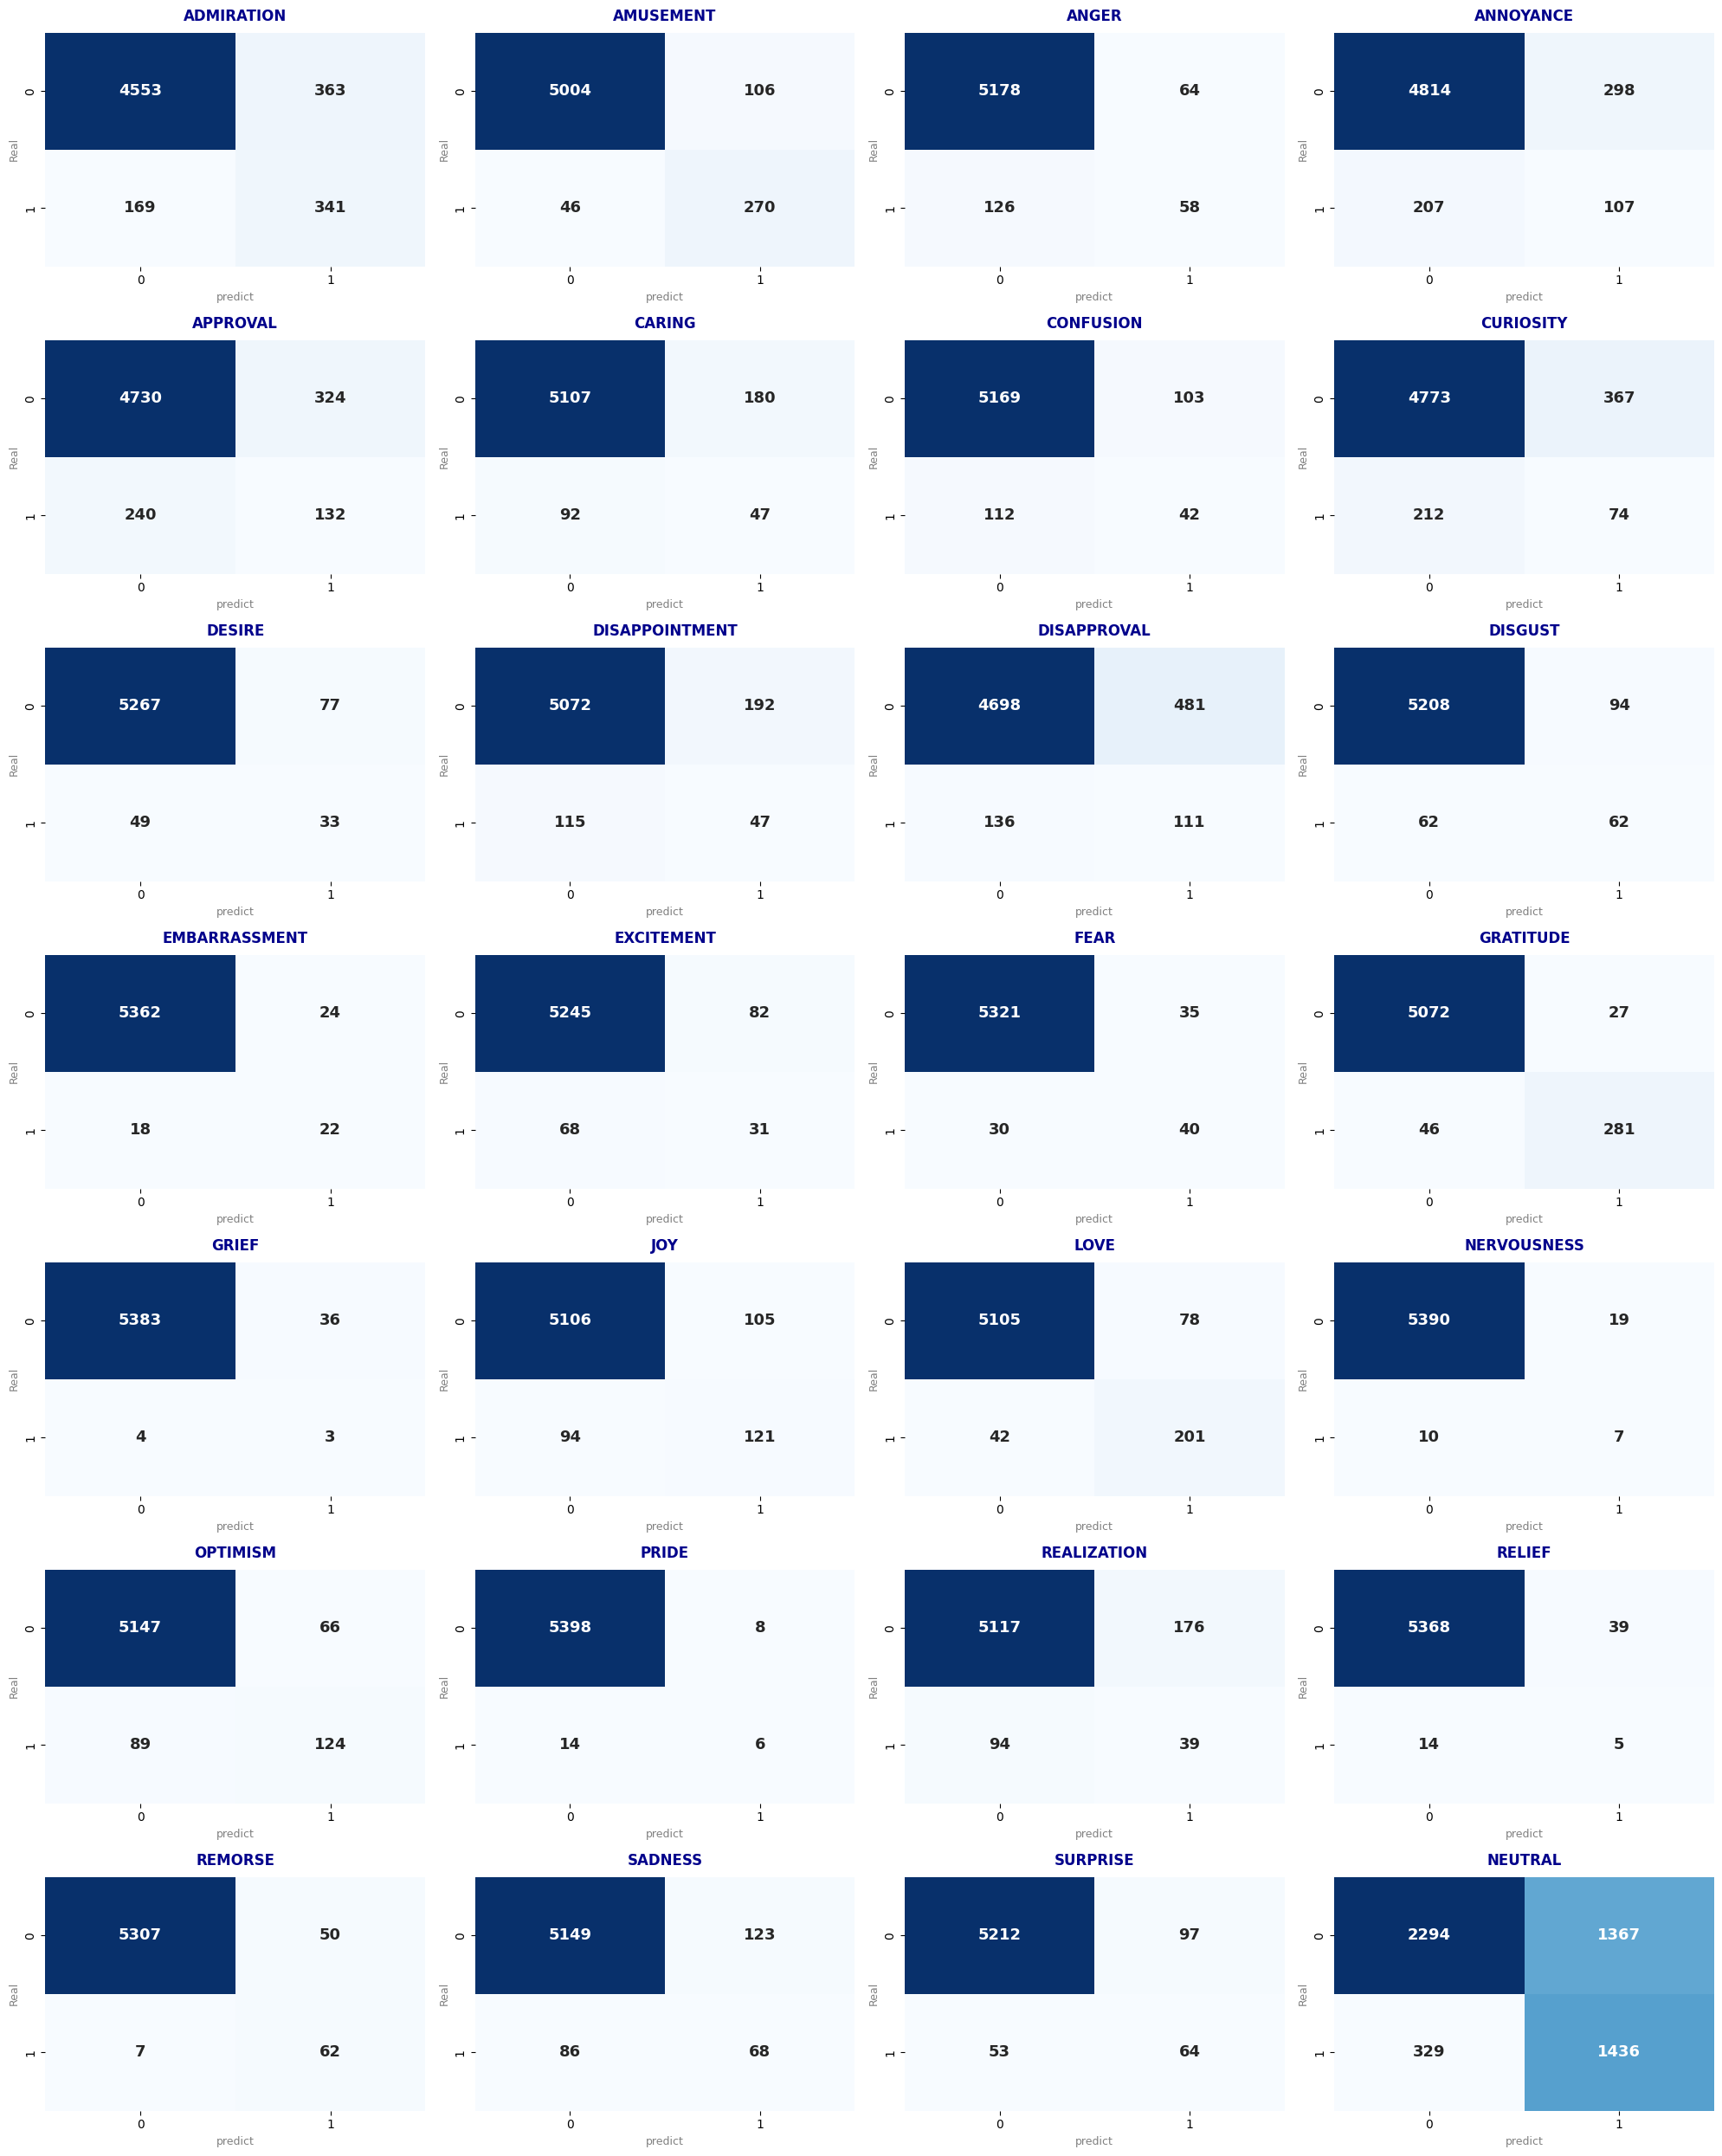

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

#(Kết quả sau khi áp dụng Threshold tối ưu)
mcm = multilabel_confusion_matrix(Y_test, Y_pred_opt)

fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, label in enumerate(emotion_labels):
    ax = axes[idx]
    sns.heatmap(mcm[idx], annot=True, fmt='d', cmap='Blues', cbar=False,
                #xticklabels=['Đoán KHÔNG', 'Đoán CÓ'],
                #yticklabels=['Gốc KHÔNG', 'Gốc CÓ'],
                ax=ax,
                annot_kws={"size": 13, "weight": "bold"})

    ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold', color='darkblue', pad=10)
    ax.set_xlabel("predict", fontsize=9, color='gray')
    ax.set_ylabel("Real", fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Live test (nhập text và dự đoán)**

In [ ]:
import numpy as np

print("Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.")
print("Gõ 'exit', 'thoat' để dừng chương trình.\n")

while True:
    user_input = input("✍️ Nhập bình luận tiếng Anh: ")

    if user_input.lower() in ['thoát', 'thoat', 'exit', 'quit']:
        print("👋 Đã đóng cổng thực nghiệm thành công!")
        break

    if user_input.strip() == "":
        continue

    # 1. Ép câu văn đi qua hàm làm sạch
    cleaned_input = advanced_clean_text(user_input)

    # 2. Ép câu sạch qua bộ trích xuất TF-IDF
    input_tfidf = tfidf.transform([cleaned_input])

    # 3. Gọi hàm predict_proba từ OneVsRestClassifier
    # Nó sẽ trả về mảng 2D kích thước (1, 28). Ta lấy hàng [0] để ra 28 điểm số.
    raw_probas = ovr_classifier.predict_proba(input_tfidf)
    scores = raw_probas[0]

    print(f'\n📝 Câu gốc nhập vào : "{user_input}"')
    print(f'✨ Sau khi làm sạch  : "{cleaned_input}"')
    print("🤖 ĐỘ TỰ TIN XÁC SUẤT CỦA 28 BỘ PHÂN LOẠI OVR:")

    activated_any = False

    # 4. Duyệt qua 28 điểm số
    for idx, score in enumerate(scores):
        label = emotion_labels[idx]

        # Lấy ngưỡng tối ưu đã tính được ở Cell 7 (nếu có lỗi chưa chạy Cell 7 thì nó tự lấy 0.5)
        threshold = best_thresholds.get(label, 0.5) if 'best_thresholds' in globals() else 0.5

        if score >= threshold:
            print(f"   - [KÍCH HOẠT] {label.upper():<15}: {score * 100:>5.2f}% (Vượt ngưỡng {threshold*100:.0f}%)")
            activated_any = True

    # 5. Cơ chế cứu trợ nếu câu quá ngắn hoặc từ vựng quá lạ
    if not activated_any:
        top_idx = np.argmax(scores)
        top_score = scores[top_idx]

        if top_score > 0.15:
            print(f"   - {emotion_labels[top_idx].upper()}: {top_score * 100:.2f}% (Sắc thái tiềm năng nhất)")
        else:
            neutral_idx = emotion_labels.index('neutral')
            neutral_score = scores[neutral_idx]
            print(f"   - NEUTRAL: {neutral_score * 100:.2f}% (Trạng thái trung tính hoàn toàn)")
    print("-" * 60)

Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.
Gõ 'exit', 'thoat' để dừng chương trình.

✍️ Nhập bình luận tiếng Anh: "Good luck with your final exam tomorrow, you'll do great!"

📝 Câu gốc nhập vào : ""Good luck with your final exam tomorrow, you'll do great!""
✨ Sau khi làm sạch  : "good luck with your final exam tomorrow you will do great!"
🤖 ĐỘ TỰ TIN XÁC SUẤT CỦA 28 BỘ PHÂN LOẠI OVR:
   - [KÍCH HOẠT] ADMIRATION     : 76.37% (Vượt ngưỡng 49%)
   - [KÍCH HOẠT] CARING         : 63.91% (Vượt ngưỡng 56%)
   - [KÍCH HOẠT] GRATITUDE      : 45.12% (Vượt ngưỡng 44%)
   - [KÍCH HOẠT] OPTIMISM       : 73.47% (Vượt ngưỡng 55%)
------------------------------------------------------------
✍️ Nhập bình luận tiếng Anh: "I laughed so hard at this that my ribs actually hurt."

📝 Câu gốc nhập vào : ""I laughed so hard at this that my ribs actually hurt.""
✨ Sau khi làm sạch  : "i laugh so hard at this that my rib actually hurt"
🤖 ĐỘ TỰ TIN XÁC SUẤT CỦA 28 BỘ PHÂN LOẠI OVR:

In [ ]:
import numpy as np
from scipy.special import expit

# HÀM MỔ XẺ TRỌNG SỐ (PHIÊN BẢN FULL 28 NHÃN)
def mose_trong_so_logistic_full(text, vectorizer, model, class_labels):
    print(f"=== ĐANG MỔ XẺ CÂU: '{text}' ===\n")

    # 1. Chuyển câu thành véc-tơ TF-IDF
    vec = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()

    # Lấy vị trí các từ có giá trị > 0
    nonzero_indices = vec.nonzero()[1]

    if len(nonzero_indices) == 0:
        print("Lỗi: Toàn bộ từ trong câu đều là stop-words hoặc chưa từng xuất hiện trong tập Train.")
        return

    print("1. ĐIỂM TF-IDF CỦA TỪNG TỪ TRONG CÂU (Đây chính là giá trị X):")
    for idx in nonzero_indices:
        print(f"   - Từ '{feature_names[idx]}': x = {vec[0, idx]:.4f}")
    print("-" * 60)

    print("2. CHI TIẾT TÍNH TOÁN CỦA TOÀN BỘ 28 MÔ HÌNH NHÃN:\n")

    results = []
    # Quét qua toàn bộ 28 mô hình (One-vs-Rest)
    for i, label in enumerate(class_labels):
        estimator = model.estimators_[i]

        # Hệ số nền b0
        b0 = estimator.intercept_[0]
        z_total = b0

        details = []
        # Cộng dồn từng điểm số (b * x)
        for idx in nonzero_indices:
            b_weight = estimator.coef_[0][idx]
            x_val = vec[0, idx]
            contribution = b_weight * x_val
            z_total += contribution
            details.append(f"      + Từ '{feature_names[idx]:>10}': Trọng số b = {b_weight:>7.4f} --> Đóng góp = {contribution:>7.4f}")

        # Ép Z qua hàm Sigmoid để ra xác suất từ 0 đến 1
        p = expit(z_total)
        results.append((label, p, b0, z_total, details))

    # ÉP MÃ: Bỏ qua mọi bước lọc, in thẳng tay cả 28 nhãn
    for label, p, b0, z, details in results:
        print(f"► MÔ HÌNH NHÃN: [{label.upper()}]")
        print(f"   - Hệ số nền (Bias b0): {b0:.4f}")
        for d in details:
            print(d)
        print(f"   => Tổng điểm thô (Z = b0 + b1x1 + ...): {z:.4f}")
        print(f"   => XÁC SUẤT QUA SIGMOID: {p:.4f}")
        print(f"   => Kết luận với Ngưỡng 0.49: {'[CÓ NHÃN NÀY]' if p > 0.49 else '[KHÔNG CÓ]'}")
        print("*" * 60 + "\n")

# CHẠY THỬ NGHIỆM
cau_van_test = "I am so excited"

mose_trong_so_logistic_full(cau_van_test, tfidf, ovr_classifier, emotion_labels)

=== ĐANG MỔ XẺ CÂU: 'I am so excited' ===

1. ĐIỂM TF-IDF CỦA TỪNG TỪ TRONG CÂU (Đây chính là giá trị X):
   - Từ 'excited': x = 1.0000
------------------------------------------------------------
2. CHI TIẾT TÍNH TOÁN CỦA TOÀN BỘ 28 MÔ HÌNH NHÃN:

► MÔ HÌNH NHÃN: [ADMIRATION]
   - Hệ số nền (Bias b0): -0.2565
      + Từ '   excited': Trọng số b = -0.0145 --> Đóng góp = -0.0145
   => Tổng điểm thô (Z = b0 + b1x1 + ...): -0.2710
   => XÁC SUẤT QUA SIGMOID: 0.4327
   => Kết luận với Ngưỡng 0.49: [KHÔNG CÓ]
************************************************************

► MÔ HÌNH NHÃN: [AMUSEMENT]
   - Hệ số nền (Bias b0): -0.6040
      + Từ '   excited': Trọng số b = -0.0111 --> Đóng góp = -0.0111
   => Tổng điểm thô (Z = b0 + b1x1 + ...): -0.6151
   => XÁC SUẤT QUA SIGMOID: 0.3509
   => Kết luận với Ngưỡng 0.49: [KHÔNG CÓ]
************************************************************

► MÔ HÌNH NHÃN: [ANGER]
   - Hệ số nền (Bias b0): -0.2525
      + Từ '   excited': Trọng số b = -0.0134 --

**Xuất file pkl**

In [ ]:
import joblib
from google.colab import files

# Lấy biến ovr_classifier (mô hình) và tfidf (vectorizer) đã train để lưu
joblib.dump(ovr_classifier, 'logistic_ovr_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("✅ Đã lưu xong mô hình vào ổ cứng Colab! Đang tự động tải về máy tính...")

# Lệnh tự động tải file xuống máy tính của bạn
files.download('logistic_ovr_model.pkl')
files.download('tfidf_vectorizer.pkl')

✅ Đã lưu xong mô hình vào ổ cứng Colab! Đang tự động tải về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>